<a href="https://colab.research.google.com/github/Hi-ImEddy/AIO/blob/feature%2FM05W02/M05W02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


EPOCH 1: Training loss: 0.300, Validation loss: 0.297

EPOCH 2: Training loss: 0.176, Validation loss: 0.174

EPOCH 3: Training loss: 0.115, Validation loss: 0.113

EPOCH 4: Training loss: 0.081, Validation loss: 0.080

EPOCH 5: Training loss: 0.062, Validation loss: 0.061

EPOCH 6: Training loss: 0.049, Validation loss: 0.049

EPOCH 7: Training loss: 0.041, Validation loss: 0.041

EPOCH 8: Training loss: 0.035, Validation loss: 0.035

EPOCH 9: Training loss: 0.031, Validation loss: 0.031

EPOCH 10: Training loss: 0.028, Validation loss: 0.027

EPOCH 11: Training loss: 0.025, Validation loss: 0.025

EPOCH 12: Training loss: 0.023, Validation loss: 0.023

EPOCH 13: Training loss: 0.021, Validation loss: 0.021

EPOCH 14: Training loss: 0.020, Validation loss: 0.020

EPOCH 15: Training loss: 0.019, Validation loss: 0.018

EPOCH 16: Training loss: 0.017, Validation loss: 0.017

EPOCH 17: Training loss: 0.017, Validation loss: 0.016

EPOCH 18: Training loss: 0.016, Validation loss: 0.015



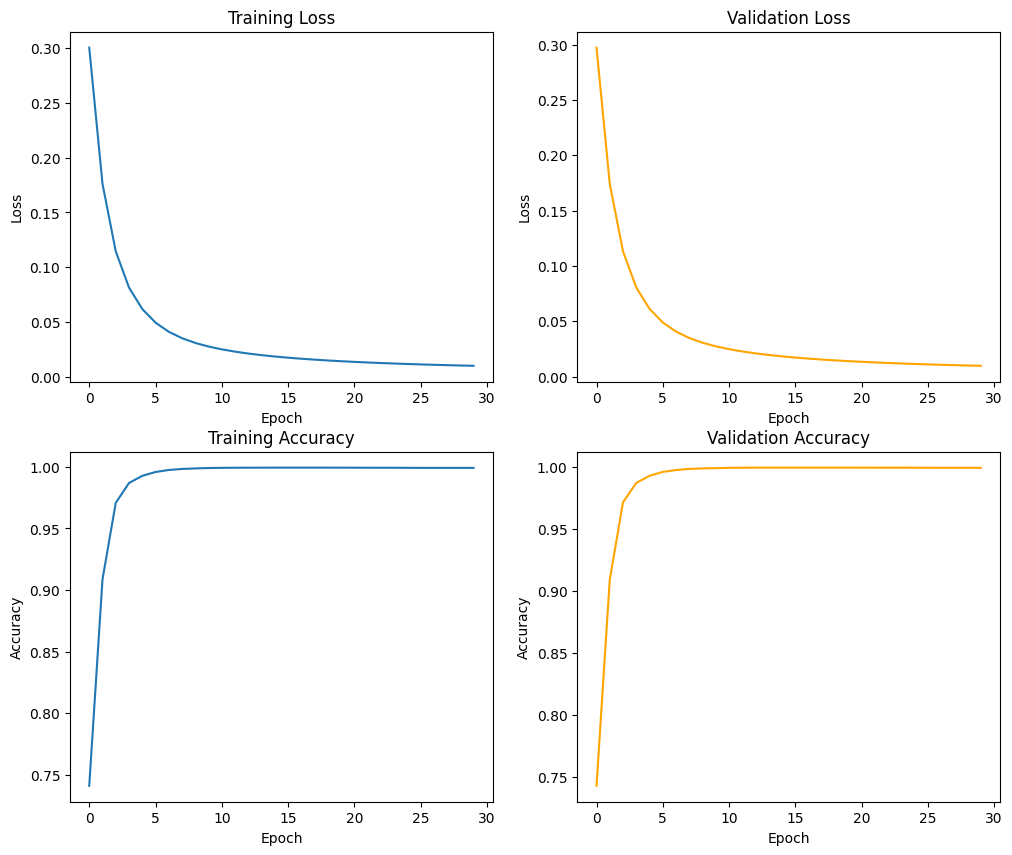

Evaluation on validation and test set:
Validation Accuracy: 0.9993153330290369
Test Accuracy: 0.9992275552122467


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
dataset_path = '/content/creditcard.csv'
df = pd.read_csv(dataset_path)

# Convert DataFrame to arrays
dataset_arr = df.to_numpy()
X, y = dataset_arr[:, :-1].astype(np.float64), dataset_arr[:, -1].astype(np.uint8)

# Add bias term
intercept = np.ones((X.shape[0], 1))
X_b = np.concatenate((intercept, X), axis=1)

# One-hot encoding labels
n_classes = np.unique(y, axis=0).shape[0]
n_samples = y.shape[0]
y_encoded = np.array([np.zeros(n_classes) for _ in range(n_samples)])
y_encoded[np.arange(n_samples), y] = 1

# Split the dataset
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True
X_train, X_val, y_train, y_val = train_test_split(X_b, y_encoded, test_size=val_size, random_state=random_state, shuffle=is_shuffle)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=test_size, random_state=random_state, shuffle=is_shuffle)

# Normalize the dataset
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

# Define necessary functions
def softmax(z):
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=1, keepdims=True)

def predict(X, theta):
    z = np.dot(X, theta)
    y_hat = softmax(z)
    return y_hat

def compute_loss(y_hat, y):
    n = y.size
    return (-1 / n) * np.sum(y * np.log(y_hat))

def compute_gradient(X, y, y_hat):
    n = y.size
    return np.dot(X.T, (y_hat - y)) / n

def update_theta(theta, gradient, lr):
    return theta - lr * gradient

def compute_accuracy(X, y, theta):
    y_hat = predict(X, theta)
    acc = (np.argmax(y_hat, axis=1) == np.argmax(y, axis=1)).mean()
    return acc

# Initialize parameters
lr = 0.01
epochs = 30
batch_size = 1024
n_features = X_train.shape[1]

np.random.seed(random_state)
theta = np.random.uniform(size=(n_features, n_classes))

# Training the model
train_accs = []
train_losses = []
val_accs = []
val_losses = []

for epoch in range(epochs):
    train_batch_losses = []
    train_batch_accs = []
    val_batch_losses = []
    val_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size):
        X_i = X_train[i:i+batch_size]
        y_i = y_train[i:i+batch_size]

        y_hat = predict(X_i, theta)

        train_loss = compute_loss(y_hat, y_i)
        gradient = compute_gradient(X_i, y_i, y_hat)

        theta = update_theta(theta, gradient, lr)

        train_batch_losses.append(train_loss)
        train_acc = compute_accuracy(X_train, y_train, theta)
        train_batch_accs.append(train_acc)

        y_val_hat = predict(X_val, theta)
        val_loss = compute_loss(y_val_hat, y_val)
        val_batch_losses.append(val_loss)
        val_acc = compute_accuracy(X_val, y_val, theta)
        val_batch_accs.append(val_acc)

    train_losses.append(np.mean(train_batch_losses))
    val_losses.append(np.mean(val_batch_losses))
    train_accs.append(np.mean(train_batch_accs))
    val_accs.append(np.mean(val_batch_accs))

    print(f'\nEPOCH {epoch + 1}: Training loss: {np.mean(train_batch_losses):.3f}, Validation loss: {np.mean(val_batch_losses):.3f}')

# Plotting the training results
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].plot(train_losses)
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_losses, 'orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(train_accs)
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot(val_accs, 'orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()

# Evaluate the model
val_set_acc = compute_accuracy(X_val, y_val, theta)
test_set_acc = compute_accuracy(X_test, y_test, theta)
print('Evaluation on validation and test set:')
print(f'Validation Accuracy: {val_set_acc}')
print(f'Test Accuracy: {test_set_acc}')


Index(['clean_text', 'category'], dtype='object')
Epoch 1/200, Training loss: 3.658, Validation loss: 3.637
Epoch 2/200, Training loss: 3.648, Validation loss: 3.628
Epoch 3/200, Training loss: 3.638, Validation loss: 3.618
Epoch 4/200, Training loss: 3.629, Validation loss: 3.609
Epoch 5/200, Training loss: 3.619, Validation loss: 3.599
Epoch 6/200, Training loss: 3.609, Validation loss: 3.590
Epoch 7/200, Training loss: 3.600, Validation loss: 3.581
Epoch 8/200, Training loss: 3.590, Validation loss: 3.571
Epoch 9/200, Training loss: 3.580, Validation loss: 3.562
Epoch 10/200, Training loss: 3.571, Validation loss: 3.553
Epoch 11/200, Training loss: 3.561, Validation loss: 3.543
Epoch 12/200, Training loss: 3.552, Validation loss: 3.534
Epoch 13/200, Training loss: 3.542, Validation loss: 3.525
Epoch 14/200, Training loss: 3.533, Validation loss: 3.516
Epoch 15/200, Training loss: 3.523, Validation loss: 3.506
Epoch 16/200, Training loss: 3.514, Validation loss: 3.497
Epoch 17/200, T

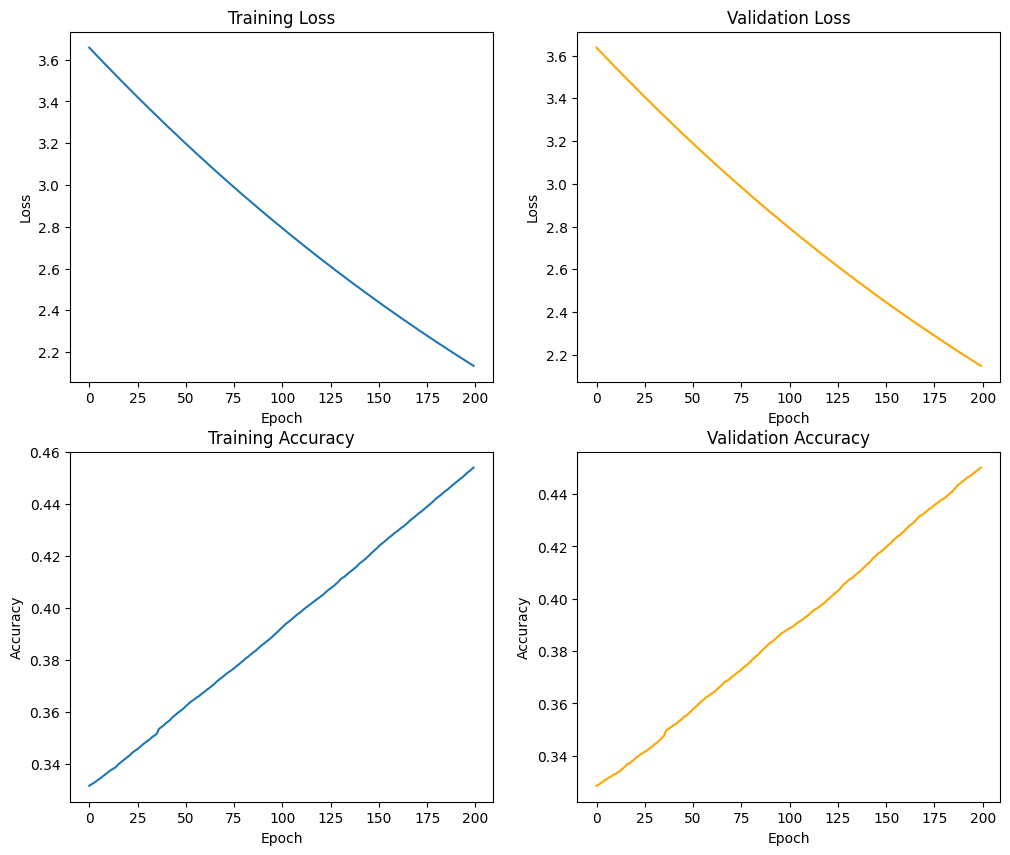

Evaluation on validation and test set:
Validation Accuracy: 0.4501135178253666
Test Accuracy: 0.44057188439590106


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.preprocessing import StandardScaler

# Load the dataset
dataset_path = '/content/Twitter_Data.csv'
df = pd.read_csv(dataset_path)

# Check if 'text' column exists or identify the actual column for text data
print(df.columns)

# Drop rows with missing data if any
df = df.dropna()

# Check if 'clean_text' column exists
if 'clean_text' not in df.columns:
    # Download stopwords if not already downloaded
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))
    stemmer = SnowballStemmer('english')

    # Define the text normalization function
    def text_normalize(text):
        # Lowercasing
        text = text.lower()
        # Remove retweet "RT" tag
        text = re.sub(r'^rt[\s]+', '', text)
        # Remove hyperlinks
        text = re.sub(r'https?://\S+', '', text)
        # Remove punctuation
        text = re.sub(r'[^\w\s]', '', text)
        # Remove stopwords
        words = text.split()
        words = [word for word in words if word not in stop_words]
        # Stemming
        words = [stemmer.stem(word) for word in words]
        return ' '.join(words)

    # Apply text normalization to the 'text' column
    df['clean_text'] = df['text'].apply(text_normalize)

# Vectorize text data with TF-IDF
vectorizer = TfidfVectorizer(max_features=2000)
X = vectorizer.fit_transform(df['clean_text']).toarray()

# Add bias term
intercept = np.ones((X.shape[0], 1))
X_b = np.concatenate((intercept, X), axis=1)

# Ensure categories are in the range 0 to n_classes - 1
# If the values are not in this range, remap them
df['category'] = df['category'].astype('category').cat.codes

# One-hot encode labels
n_classes = df['category'].nunique()
n_samples = df['category'].size
y = df['category'].to_numpy().astype(np.uint8)
y_encoded = np.array([np.zeros(n_classes) for _ in range(n_samples)])
y_encoded[np.arange(n_samples), y] = 1

# Split the dataset into train, validation, and test sets
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True
X_train, X_val, y_train, y_val = train_test_split(X_b, y_encoded, test_size=val_size, random_state=random_state, shuffle=is_shuffle)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=test_size, random_state=random_state, shuffle=is_shuffle)

# Normalize the dataset
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

# Define necessary functions
def softmax(z):
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=1, keepdims=True)

def predict(X, theta):
    z = np.dot(X, theta)
    y_hat = softmax(z)
    return y_hat

def compute_loss(y_hat, y):
    n = y.size
    return (-1 / n) * np.sum(y * np.log(y_hat))

def compute_gradient(X, y, y_hat):
    n = y.size
    return np.dot(X.T, (y_hat - y)) / n

def update_theta(theta, gradient, lr):
    return theta - lr * gradient

def compute_accuracy(X, y, theta):
    y_hat = predict(X, theta)
    acc = (np.argmax(y_hat, axis=1) == np.argmax(y, axis=1)).mean()
    return acc

# Initialize parameters
lr = 0.1
epochs = 200
batch_size = X_train.shape[0]
n_features = X_train.shape[1]

np.random.seed(random_state)
theta = np.random.uniform(size=(n_features, n_classes))

# Training the model
train_accs = []
train_losses = []
val_accs = []
val_losses = []

for epoch in range(epochs):
    y_hat = predict(X_train, theta)
    train_loss = compute_loss(y_hat, y_train)
    gradient = compute_gradient(X_train, y_train, y_hat)

    theta = update_theta(theta, gradient, lr)

    train_acc = compute_accuracy(X_train, y_train, theta)
    val_loss = compute_loss(predict(X_val, theta), y_val)
    val_acc = compute_accuracy(X_val, y_val, theta)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Epoch {epoch + 1}/{epochs}, Training loss: {train_loss:.3f}, Validation loss: {val_loss:.3f}')

# Plotting the training results
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].plot(train_losses)
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_losses, 'orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(train_accs)
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot(val_accs, 'orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()

# Evaluate the model
val_set_acc = compute_accuracy(X_val, y_val, theta)
test_set_acc = compute_accuracy(X_test, y_test, theta)
print('Evaluation on validation and test set:')
print(f'Validation Accuracy: {val_set_acc}')
print(f'Test Accuracy: {test_set_acc}')
